In [98]:
listy = [10,9,8,7,6]
# listy.pop(0)
listy.pop(-1)

6

In [101]:
3*188/4

141.0

In [1]:
import os
import os

import yaml


import numpy as np
import scipy.stats as stats
import sys
repo_dir = '/work/westgroup/ChrisB/_01_MeOH_repos/uncertainty_analysis'
if repo_dir not in sys.path:
    sys.path.append(repo_dir)
from rmg_gua.plotting.make_paper_plots import meoh_plots
from make_paper_plots import meoh_plots

cantera version:  2.6
cantera version:  2.6


[c0403:26726] mca_base_component_repository_open: unable to open mca_btl_openib: libosmcomp.so.3: cannot open shared object file: No such file or directory (ignored)


In [83]:
project_path = "/work/westgroup/ChrisB/_01_MeOH_repos/00_thesis_data/peuqse_runs/peuqse_methanol_07Aug/"
paper_plots = meoh_plots(
    project_path, 
    by_species = True, 
    output_species = ["CH3OH", "H2O"], 
)

Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
start time: Mon Aug 12 19:09:30 2024
end time: Mon Aug 12 19:09:35 2024
elapsed: 5.483628749847412 seconds
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipping...
Cantera version is too old for preconditioning, skipp

In [89]:
graaf_expt

{'catalyst_area': 48.86661230037379,
 'experiment_type': 'sbr',
 'expt_name': 'graaf_1988',
 'output': {'CH3OH': 0.0008257685305560042, 'H2O': 0.000994675729987914},
 'pressure': 1530000.0,
 'run_num': 1.0,
 'species': {'CO': 0.065, 'CO2': 0.261, 'H2': 0.674},
 'species_out': {'CH3OH': 0.0044,
  'CO': 0.0675,
  'CO2': 0.2553,
  'H2': 0.6675,
  'H2O': 0.0053},
 'temperature': 483.5,
 'use_for_opt': True,
 'volume': 0.0001346957850226624,
 'volume_flowrate': 6e-06}

In [90]:
import copy
for expt in paper_plots.all_graaf_expts:
    if expt["temperature"] < 500: 
        graaf_expt = copy.deepcopy(expt)
        graaf_expt['catalyst_area'] = expt['catalyst_area']+7.06
        print(graaf_expt['catalyst_area'], expt['catalyst_area']) 
        break

51.48419300033981 44.424193000339805


In [91]:
# yaml_path = os.path.join(project_path, "map_mechanism.yaml")
reactime = 4000
yaml_path = os.path.join(project_path, "rmg_model", "cantera", "chem_annotated.yaml")
sbr = paper_plots.get_min_sbr(yaml_path)
sbr.reset_reactor(        
    reac_config=graaf_expt, 
    rtol=1.0e-11,
    atol=1.0e-22,
    )
sbr.time = reactime 

Cantera version is too old for preconditioning, skipping...


In [92]:
from time import time
dt = 5.0
start_time = time()
results = sbr.run_reactor_transient(dt=dt)
end_time = time()

print("elapsed: ", end_time - start_time)

elapsed:  3.724555730819702


In [93]:
times = np.arange(0, sbr.time, dt)

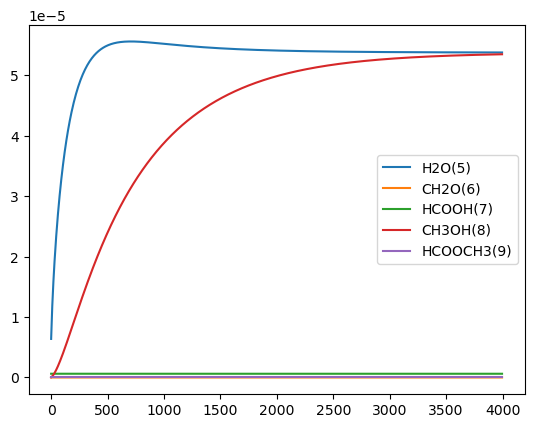

In [94]:
import matplotlib.pyplot as plt
gas_spec_labels = [
    # 'H2(2)',
    # 'CO(3)',
    # 'CO2(4)',
    'H2O(5)',
    'CH2O(6)',
    'HCOOH(7)',
    'CH3OH(8)',
    'HCOOCH3(9)',
]
for spec in gas_spec_labels:
    plt.plot(times, results[spec], label=spec)

plt.legend()
# list(results.keys())

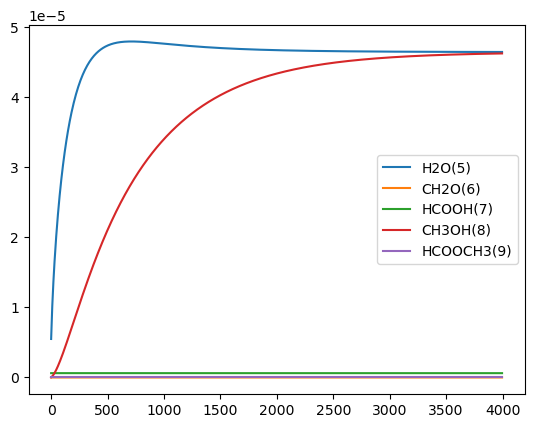

In [50]:
import matplotlib.pyplot as plt
gas_spec_labels = [
    # 'H2(2)',
    # 'CO(3)',
    # 'CO2(4)',
    'H2O(5)',
    'CH2O(6)',
    'HCOOH(7)',
    'CH3OH(8)',
    'HCOOCH3(9)',
]
for spec in gas_spec_labels:
    plt.plot(times, results[spec], label=spec)

plt.legend()
# list(results.keys())

In [10]:
graaf_expt

{'catalyst_area': 44.424193000339805,
 'experiment_type': 'sbr',
 'expt_name': 'graaf_1988',
 'output': {'CH3OH': 0.0017356153114958925, 'H2O': 0.0033898736552654147},
 'pressure': 1500000.0,
 'run_num': 13.0,
 'species': {'CO': 0.065, 'CO2': 0.261, 'H2': 0.674},
 'species_out': {'CH3OH': 0.0064,
  'CO': 0.0722,
  'CO2': 0.2489,
  'H2': 0.66,
  'H2O': 0.0125},
 'temperature': 516.7,
 'use_for_opt': True,
 'volume': 0.0001346957850226624,
 'volume_flowrate': 8.67e-06}

In [21]:
results["CH3OH(8)"][-1]

0.0001242570448966402

In [11]:
results["CH3OH(8)"][-1]

0.00014665466136639215

In [30]:
results["CH3OH(8)"][-1]

0.00014698403835644672

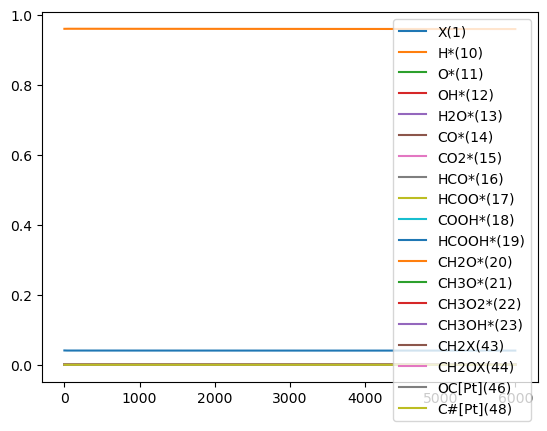

In [31]:
surf_spec_labels = [
    'X(1)',
    'H*(10)',
    'O*(11)',
    'OH*(12)',
    'H2O*(13)',
    'CO*(14)',
    'CO2*(15)',
    'HCO*(16)',
    'HCOO*(17)',
    'COOH*(18)',
    'HCOOH*(19)',
    'CH2O*(20)',
    'CH3O*(21)',
    'CH3O2*(22)',
    'CH3OH*(23)',
    'CH2X(43)',
    'CH2OX(44)',
    'OC[Pt](46)',
    'C#[Pt](48)',
]


for spec in surf_spec_labels:
    plt.plot(results[spec], label=spec)

plt.legend()


In [20]:
results['graaf MeOH TOF 1/s'],results['graaf H2O TOF 1/s'],results['RMG MeOH TOF 1/s'][-1],results['RMG H2O TOF 1/s'][-1],

(0.0008257685305560042,
 0.000994675729987914,
 7.02753522478909e-10,
 1.7919901003058154e-07)

In [25]:
sbr.gas.P/1e5
sbr.gas.T

483.5

In [53]:
paper_plots.uncerts

{'catalyst_area': [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
 'pressure': [1000.0,
  1000.0,
  1000.0,
  1000.0,
  1000.0,
  1000.0,
  1000.0,
  1000.0,
  1000.0,
  1000.0,
  1000.0,
  1000.0],
 'species_CO': [0.0,
  0.0012,
  0.0,
  0.0012,
  0.0012,
  0.0012,
  0.0,
  0.0012,
  0.0,
  0.0012,
  0.0012,
  0.0012],
 'species_CO2': [0.00115,
  0.00021,
  0.00115,
  0.00021,
  0.00021,
  0.00021,
  0.00115,
  0.00021,
  0.00115,
  0.00021,
  0.00021,
  0.00021],
 'species_H2': [0.00885,
  0.00859,
  0.00885,
  0.00859,
  0.00859,
  0.00859,
  0.00885,
  0.00859,
  0.00885,
  0.00859,
  0.00859,
  0.00859],
 'species_H2O': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'species_out_CH3OH': [0.000119,
  6.3e-05,
  6.3e-05,
  3.4e-05,
  8.4e-05,
  0.000133,
  0.000207,
  5.1000000000000006e-05,
  0.000129,
  0.00019,
  0.000183,
  8.3e-05],
 'species_out_CO': [4.3e-05,
  0.00117,
  2.1e-05,
  0.0011870000000000001,
  0.001145,
  0.001119,
  3.9e-05,
  0.001181,
  2.5e-05,
  0.001097,
  0.001087,
  0.001